In [1]:
# suppress tensorflow logging, usually not useful unless you are having problems with tensorflow or accessing gpu
# it seems necessary to have this environment variable set before tensorflow is imported, or else it doesn't take effect
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 

# imports generally useful throughout the notebook
# usually all imports should happen at the top of a notebook, but in
# these notebooks where the purpose is to show how to use the Keras API
# the relevant imports will happen in the cells where the API is discussed
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# global settings for notebook output and images
plt.rcParams['figure.figsize'] = (8, 8) # set default figure size, 10in by 8in
np.set_printoptions(precision=4, suppress=True)

In [2]:
# import project defined modules / functions used in this notebook
# ensure that the src directory where project modules are found is on
# the PYTHONPATH
import sys
sys.path.append("../src")

# assignment function imports for doctests and github autograding
# these are required for assignment autograding
from nndl import vectorize_samples, plot_history

In [3]:
# if want to restrict to cpu or gpu, configure visible device for rest of notebook to use
dev = tf.config.list_physical_devices()
print('Physical Devices : ', dev)

#tf.config.set_visible_devices(dev[0])
#tf.config.set_visible_devices(dev[1])
#dev = tf.config.list_logical_devices()
print('Available Devices : ', dev)

Physical Devices :  [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Available Devices :  [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# Chapter 8: Introduction to Deep Learning for Computer Visison

Supporting materials for:

Chollet (2021). *Deep Learning with Python*. 2nd ed. Manning Publications Co.
[Amazon](https://www.amazon.com/Learning-Python-Second-Fran%C3%A7ois-Chollet/dp/1617296864/ref=sr_1_1?crid=32NFM2SBCJVQQ)

**Convolutional neural networks** also known as **convnets**, are introduced in this chapter. 
Computer vision is the earliest and biggest success story of deep learning.  
A type of deep learning model called convolutional
neural networks started getting remarkably good results on image classification
competitions in the early 2010's. In these sections we will look at what
convnets are and how to use them to solve computer vision and image
classificatin tasks.

## 8.2 Training a Convnet from Scratch on a Small Dataset

Having to train an image-classification model using very little data is a common situation,
which you’ll likely encounter in practice if you ever do computer vision in a
professional context.

In this example, we will use the dog or cat dataset, which we have run across before.  This is an
binary image classification task.  The dataset contains 5000 images of cats and dogs, evenly
split (2500 cats, 2500 dogs).  We'll use 2000 images for training, 1000 for validation and 2000 for
final testing.


We’ll start by naively training a small convnet on the 2,000 training samples, without any regularization, to set a baseline
for what can be achieved, which you will see will be about 70%.

The model will be overfitting.  We will introduce **data augmentation** then, a powerful technique for
mitigating overfitting in computer vision tasks.  Adding data augmentation should improve the accuracy to 80-85%.

### 8.2.1 The Relevance of Deep Learning for small-data Problems

What qualifies as “enough samples” to train a model is relative—relative to the size
and depth of the model you’re trying to train.

It isn’t possible to train a
convnet to solve a complex problem with just a few tens of samples, but a few hundred
can potentially suffice if the model is small and well regularized and the task is simple.

### 8.2.2 Downloading the Data

The Dogs vs. Cats dataset that we will use isn’t packaged with Keras. It was made available
by Kaggle as part of a computer vision competition in late 2013.

You can download the original dataset from [Kaggle](https://www.kaggle.com/c/dogs-vs-cats/data)

**Note**: As the text notes, you will need a Kaggle account and to log in to download the zip.  The file is 800+ Mb
in size, so it is not included in the class repository.  The following code assumes that the data is unzipped
and placed in the `../data/dogs-vs-cats/` subdirectory, and that the test and train zips in the larger zip are unzipped, so
that the foler `..data/dogs-vs-cats/train` is available for the next step.


The zip file you download from Kaggle actually contains 25,000 images of dogs and cats in the training set (evenly
split with 12,500 examples of each category).  After downloading and unzipping the data, we'll create a new dataset
containing three subsets: a training set with 1,000 samples of each class, a validation set with 500 samples of each class, and
a test set with 1,000 samples of each class.  

We will also give a particular structure to the subsampled dataset with the following structure:

```
cats_vs_dogs_small/
...train/
......cat/
......dog/
...validation/
......cat/
......dog/
...test/
......cat/
......dog/
```

You will see this kind of structure setup is needed by some `Keras` dataset loading and batching functions.

The following will sample the larger dataset and make our small subsambled dataset with the needed directory
structure.

In [4]:
import os, shutil, pathlib

# modify the path to where you unzipped the kaggle train images
original_dir = pathlib.Path("../data/dogs_vs_cats/train")
# top level director where we will store our smaller dataset 
new_base_dir = pathlib.Path("../data/cats_vs_dogs_small")


def make_subset(subset_name, start_index, end_index):
    """Create a subset of images for this example, this function
    can be used to create the train, validation and test sets.

    Parameters
    ----------
    subset_name : str
      The subset name, will create top level directory under base directory
    start_index : int
      The start index of original directory images, all images are numbered 0..25000 for both
      the cat and dog pictures.  This is the start index used for both categories
    end_index : int
      The end index of original directory images.  Using 0-based indexing so end_index is non-inclusive.
    """
    for category in ("cat", "dog"):
        dir = new_base_dir / subset_name / category
        os.makedirs(dir)
        fnames = [f"{category}.{i}.jpg" for i in range(start_index, end_index)]
        for fname in fnames:
            shutil.copyfile(src=original_dir / fname, dst=dir / fname)
            print('.', end='')
    print('')

# Note: added in test of the new_base_dir and if it already exists we
# assume the subsets have already been created
if not os.path.isdir(new_base_dir):
    # create training subset with first 1,000 images from original Kaggle dataset
    print('create train data: ', end='')
    make_subset('train', start_index=0, end_index=1000)
    
    # create validation subset with next 500 images
    print('create validation data: ', end='')
    make_subset('validation', start_index=1000, end_index=1500)
    
    # create test subset with next 1000 images
    print('create test data: ', end='')
    make_subset('test', start_index=1500, end_index=2500)

Here are a few random cat and dog images from the training samples.  Notice, all of the images are of different sizes, we will have
to do something about that...

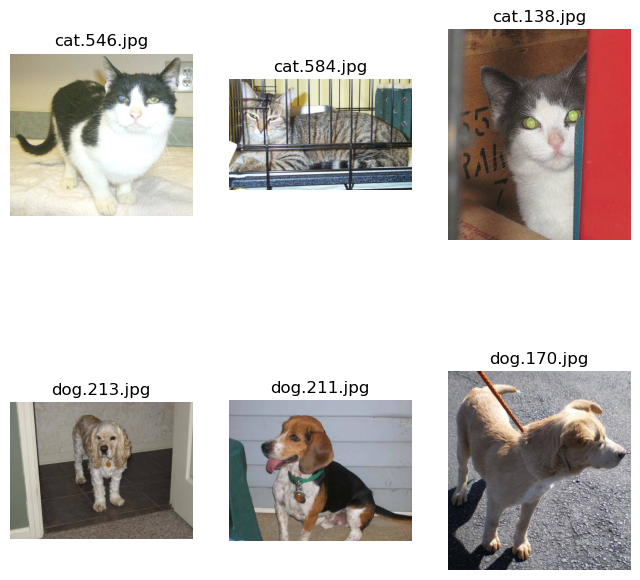

In [5]:
plt_idx = 1
for category in ("cat", "dog"):
    for rnd_idx in np.random.choice(np.arange(0, 1000), (3,), replace=False):
        fname = f"{category}.{rnd_idx}.jpg"
        src = new_base_dir / "train" / category / fname
        img = plt.imread(src)
        ax = plt.subplot(2, 3, plt_idx)
        plt.imshow(img)
        plt.title(fname)
        ax.set_axis_off()
        plt_idx += 1

### 8.2.3 Building the Model

We will be reusing some of the same structure from the first example model.  The convnet will be a stack of alternated
`Conv2D` (with `relu` activation) and `MaxPooling2D layers.

The images here are bigger and more complex (3 color channel inputs for example).  We'll need to make our
model larger as a result, it will have two more `Conv2D` and `MaxPooling2D` layers than before.  This
serves both to augment representational capacity.  And because we downsample and additional 2 times,
the size of the feature maps at the top of the hierarchy will not be overly large for the final
`Dense` layer to handle.

We will be resizing all input images to 180x180 pixels (an arbitrary choice).  Because we start with
180x180 pixels, we end up with feature maps of size 7x7, which you will be able to see from
the model summary.

**Note**: The depth of the feature maps progressively increases in this model (from 32 to 256),
whereas the size of the feature maps decreases (from 180x180 to 7x7).  This is a common pattern
you'll see in almost all convnets.

Because this is a binary classifiction problem, we will end with a `Dense` layer with `sigmoid`
output activation.  This unit will encode the probability that the image is a "cat" 0 or a "dog" 1.

On last small difference.  The model starts with a `Rescaling` layer. This layer will handle
rescaling the RGB integer inputs in range 0-255 to the [0,1] range.

In [6]:
# the model expects RGB images of size 180x180, we haven't dealt with how to resize images for input yet
inputs = keras.Input(shape=(180, 180, 3))
# rescale inputs to the [0,1] range by dividing RGB pixel values by 255
x = layers.Rescaling(1./255)(inputs)
x = layers.Conv2D(filters=32, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=64, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=128, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.Flatten()(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs=inputs, outputs=outputs)

I0000 00:00:1749578677.296918   43084 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9706 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:01:00.0, compute capability: 8.6


Let's look at the model dimensions and confirm some of the things discussed above.

In [7]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 41, 41, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 18, 18, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │        12,545 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 991,041 (3.78 MB)

 Trainable params: 991,041 (3.78 MB)

 Non-trainable params: 0 (0.00 B)

The output shape from the layers here should be understandable to you from our previous discussion of convolutions and maxpooling.
Input and rescaling expect images of shape `(180, 180, 3)`, with 3 RGB color channels originally that are rescaled to `[0,1]` range.

The shape after first convolution becomes `(178, 178, 32)`, because we are not using any striding (stride=1) and we ask for this layer to 
learn a convolution kernal of 32 features on the 3x3 sized patches.

The first maxpooling layers is downsampling 2x2, so the shape is reduced to `(89, 89, 32)`.  

The same process happens for each subsequent convolution and maxpooling.  We are always using a 3x3 sized kernel window and a 2x2 maxpooling downsample.  Notice that downsampling
will round down when using 2x2 if the previous widthxheight is odd.

The final convolution produces 256 feature maps over a `(7,7)` shaped representation.  The 7x7x256=12544 values are flattened and fed into the final `Dense` layer for
final categorization.

For the compilation step we will use the usual `RMSprop` optimizer, `binary_crossentropy` loss function, and ask for `accuracy` metrics to be evaluated when training.

In [8]:
model.compile(loss="binary_crossentropy",
              optimizer="rmsprop",
              metrics=["accuracy"])

### 8.2.4 Data Preprocessing

As you know, the data should be formatted into appropriately preprocessed floating-point tensors ( `(180,180,3)` pixels
with 3 color channels, still encoded as integer RGB values 0-255).

The data is currently in a directory as JPEG files.  So for getting the JPEG files into our model we will need to do the following:

1. Read the picture files
2. Decode the JPEG content to RGB grids of pixels.
3. Convert these into floating-point tensors. (doesn't the rescaling layer do that?)
4. Resize them to a standard size (we'll use 180 x 180)
5. Pack them into batches (we'll use batches of 32 images).

This is a bit daunting, but common enough that Keras has utilities for some common dataflows like this that we can usually use.

The Keras utility `image_dataset_from_directory()` lets you quickly set up a datapipeline that can automatically turn
image files on disk into batches of preprocessed tensors.  This function expectes the directory structure to be in
a particular format, which is why our sampling process set up the directories that way.

Calling `image_dataset_from_directory(directory)` will first list the subdirectories of `directory` and assume each one
contains images fom one of our classes.  It will then index the image files in ech subdirectory.  Finally it will create and
return a `tf.data.Dataset` object configured to read thos files, shuffle them, decode them to
tensors, resize them to a shared saze, and pack them into batches. (Thankfully for us!)

In [9]:
from tensorflow.keras.utils import image_dataset_from_directory

# notice the image_size and batch_size parameters here
train_dataset = image_dataset_from_directory(
    new_base_dir / "train",
    image_size=(180, 180),
    batch_size=32)

validation_dataset = image_dataset_from_directory(
    new_base_dir / "validation",
    image_size=(180, 180),
    batch_size=32)

test_dataset = image_dataset_from_directory(
    new_base_dir / "test",
    image_size=(180, 180),
    batch_size=32)

Found 2000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.
Found 2000 files belonging to 2 classes.


#### Understanding TensorFlow `Dataset` objects

- TensorFlow makes available the tf.data API to create efficient input pipelines for machine learning models.
- A `Dataset` object is an iterator: you can use it in a `for` loop.
  - Typically returns batches of input data and labels.
  - Can pass a `Dataset` object directly to the `fit()` method of Keras models.
- `Dataset` can be very helpful, asynchronous data prefetching
- `Dataset` exposes a functional-style API for modifying datasets.

In [10]:
# random numbers for an example, 
random_numbers = np.random.normal(size=(1000, 16))
# from_tensor_slices can be used to create a Dataset from a NumPy array, tuple or dict
dataset = tf.data.Dataset.from_tensor_slices(random_numbers)

In [11]:
# if used in an iterator, will just yield single samples
for i, element in enumerate(dataset):
    print(element.shape)
    if i >= 2:
        break

(16,)
(16,)
(16,)


In [12]:
# can use .batch() to batch the data, this is what fit() does for specified batch_size
batched_dataset = dataset.batch(32)
for i, element in enumerate(batched_dataset):
    print(element.shape)
    if i >= 2:
        break

(32, 16)
(32, 16)
(32, 16)


More broadly, there are a range of useful dataset methods such as:

- `.shuffle(buffer_size)` Shuffles elementes within a buffer
- `.prefetch(buffer_size)` Prefetches a buffer of elements in GPU memory to achieve better device utilization
- `.map(callable)` Applies an arbitrary transformation to each element of the dataset.

The `.map()` method in particular is one that you will often use.  Here's an example.  We'll use it to reshape the elements of
our toy dataset from shape (16,) to shape (4,4):

In [13]:
reshaped_dataset = dataset.map(lambda x: tf.reshape(x, (4, 4)))
for i, element in enumerate(reshaped_dataset):
    print(element.shape)
    if i >= 2:
        break

(4, 4)
(4, 4)
(4, 4)


Let's look at the output of our `train_dataset` object.  It yields batches of 180x180 RGB images
(shape `(32, 180, 180, 3)` and integer labels (shape `(32,)`).  There are 32 samples in each batch,
the batch size specified when we created the `Dataset`.

In [14]:
# here is the train_dataset we created
print(type(train_dataset))
print(train_dataset.class_names)

<class 'tensorflow.python.data.ops.prefetch_op._PrefetchDataset'>
['cat', 'dog']


In [15]:
for data_batch, labels_batch in train_dataset:
    print('data batch shape:  ', data_batch.shape)
    print('data batch type:   ', type(data_batch))
    print('data batch dtype:  ', data_batch.dtype)
    print('labels batch shape:', labels_batch.shape)
    print('labels batch type: ', type(labels_batch))
    print('labels batch dtype:', labels_batch.dtype)
    break

data batch shape:   (32, 180, 180, 3)
data batch type:    <class 'tensorflow.python.framework.ops.EagerTensor'>
data batch dtype:   <dtype: 'float32'>
labels batch shape: (32,)
labels batch type:  <class 'tensorflow.python.framework.ops.EagerTensor'>
labels batch dtype: <dtype: 'int32'>


labels batch first label: tf.Tensor(0, shape=(), dtype=int32)


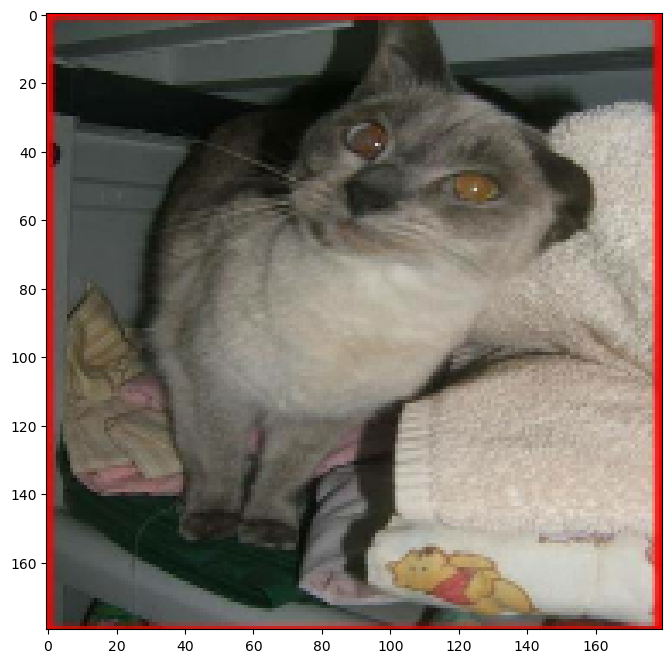

In [16]:
# look at first item, note that 0 labels are cats and 1 are dogs, and that images are now 180,180 pixels
print('labels batch first label:', labels_batch[0])
img = data_batch[0].numpy().astype(int)
plt.imshow(img);

#### Fit the model on dataset

Let's fit the model on the dataset.  We'll use `validation_data` argument in `fit()`
to monitor validation metrics on a separate `Dataset` object.

Note we are also using a `ModelCheckpoint` callback to save the best model seen so far, where we will monitor
validation loss and save the model having the lowest validation loss in a run.

In [17]:
# use model checkpoint to save best seen model (model with lowest validation loss)
callbacks = [
    keras.callbacks.ModelCheckpoint(
    filepath="../models/ch08-convnet-from-scratch.keras",
    save_best_only=True,
    monitor="val_loss")
]

history = model.fit(
    train_dataset,
    epochs=30,
    validation_data=validation_dataset,
    callbacks=callbacks)

Epoch 1/30


I0000 00:00:1749578766.807212   43202 service.cc:152] XLA service 0x7efa6400a1a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1749578766.807291   43202 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 3060, Compute Capability 8.6
2025-06-10 18:06:06.880168: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1749578767.101144   43202 cuda_dnn.cc:529] Loaded cuDNN version 90300


 5/63 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.5156 - loss: 0.7169

I0000 00:00:1749578772.367174   43202 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 119ms/step - accuracy: 0.5092 - loss: 0.6991 - val_accuracy: 0.5010 - val_loss: 0.6906
Epoch 2/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.5415 - loss: 0.6950 - val_accuracy: 0.6690 - val_loss: 0.6736
Epoch 3/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.6316 - loss: 0.6902 - val_accuracy: 0.6830 - val_loss: 0.6211
Epoch 4/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.6455 - loss: 0.6524 - val_accuracy: 0.6570 - val_loss: 0.6155
Epoch 5/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.6795 - loss: 0.6114 - val_accuracy: 0.6450 - val_loss: 0.7379
Epoch 6/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.6918 - loss: 0.5808 - val_accuracy: 0.6530 - val_loss: 0.6295
Epoch 7/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.7173 - loss: 0.5620 - val_accuracy: 0.7210 - val_loss: 0.5357
Epoch 8/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.7694 - loss: 0.4814 - val_accuracy: 0.7000 - val_loss: 

Let's plot the loss and accuracy learning curves of the model of the training and validation data during this
training run.

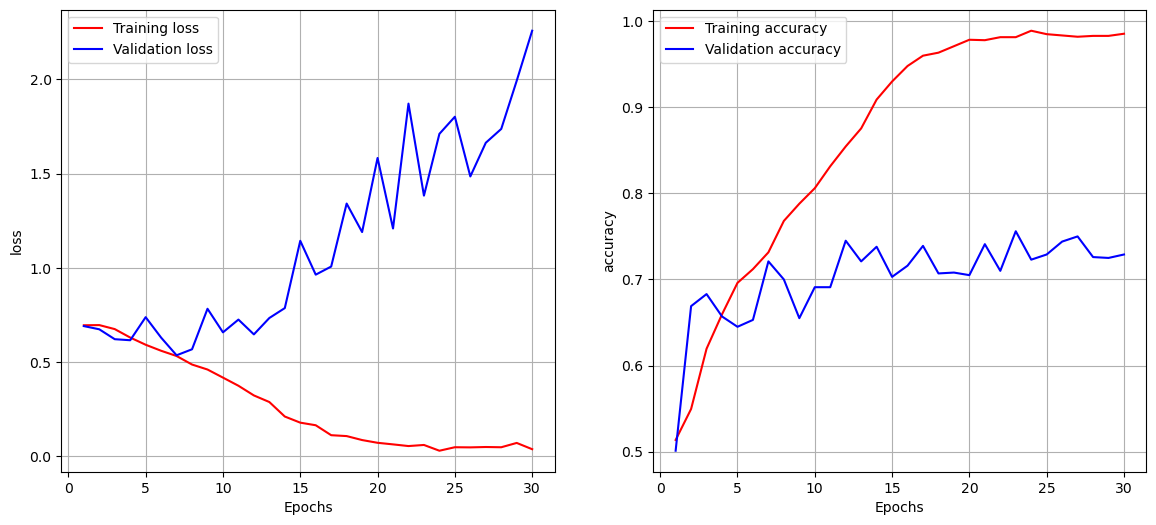

In [18]:
plt.figure(figsize=(14,6))
ax_loss = plt.subplot(1, 2, 1)
plot_history(ax_loss, history.history, 'loss')
ax_acc = plt.subplot(1, 2, 2)
plot_history(ax_acc, history.history, 'accuracy')

You should recognize in this class what the loss plot means here.  These plots are characteristic of overfitting.  The training
accuracy increases until it reaches nearly 100% and loss goes down to almost 0.  But the validation accuracy peaks somewhere between epoch
10 to 15, and accuracy loss starts increasing while the validation accuracy should usually peak around 75%.

Let's check the test accuracy.  We'll reload the model from its saved file to evaluate it before we started overfitting.  The model that had
the lowest validation loss should be saved in the file we asked the checkpoint callback to create.

In [19]:
test_model = keras.models.load_model("../models/ch08-convnet-from-scratch.keras")
test_loss, test_acc = test_model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.3f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.7182 - loss: 0.5547
Test accuracy: 0.726


Textbook thinks you usually shouldn't get higher than 71%, but I do sometimes see test accuracies as high as 74% or so on the best model.

Because we have relatively few training samples (2,000) overfitting will be our main concern.  You already know of a number of
techniques to improve generalization, such as dropout layers, weight decay (L2 Regularization).  We applied one here and performed early stopping.

We will now look at a new one that is specific to computer vision and image classification problems and used frequently when
processing images with deep learning models: **data augmentation**.

### 8.2.5 Using Data Augmentation

Overfitting is caused by having too few samples to learn from (density of samples is insufficient to
represent the manifold) rendering you unable to train a model that can generalize to new data.

Data augmentation takes the approach of generating more trainign data from existing training samples, by
**augmenting** the samples via a number of random transformations that yield believable-loking images.
The goal is that, at training time,
your model will never see the exact same picture twice. This helps expose the model
to more aspects of the data so it can generalize better.

In terms of the manifold theory that we discussed previously, for some types of data, like images,
it is possible to generate new samples from existing images that could possibly be on the data
manifold.  So we can get a more dense sampling of the possible manifold in this way.

Again Keras has some high-level functions that make data augmentation easy for
image processing: **data augmentation layers**.  By adding data augmentation layers at the start
of yourmodel, you can generate random perturbations of your images will can greatly help overfitting
in image processing tasks.

In our model we'd include it right before the rescaling layer.

In [20]:
# define a data augmentation stage to add to our image model
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.2),
    ]
)

There are others possible.  The ones we are using in this example include:

- `RandomFlip` - can flip images along horizontal or vertical axis, or both, we do only horizontal here.  Applies it to 50% of images that go though by default.
- `RandomRotation(0.1)` - Rotates the input images by a random value in the range -10% to +10%.
- `RandomZoom(0.2)` - Zooms in or out of the image by a random factor in the range -20% to +20%

Let's look at some examples of applying the defined random augmentations to an image.


2025-06-10 18:12:06.587962: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


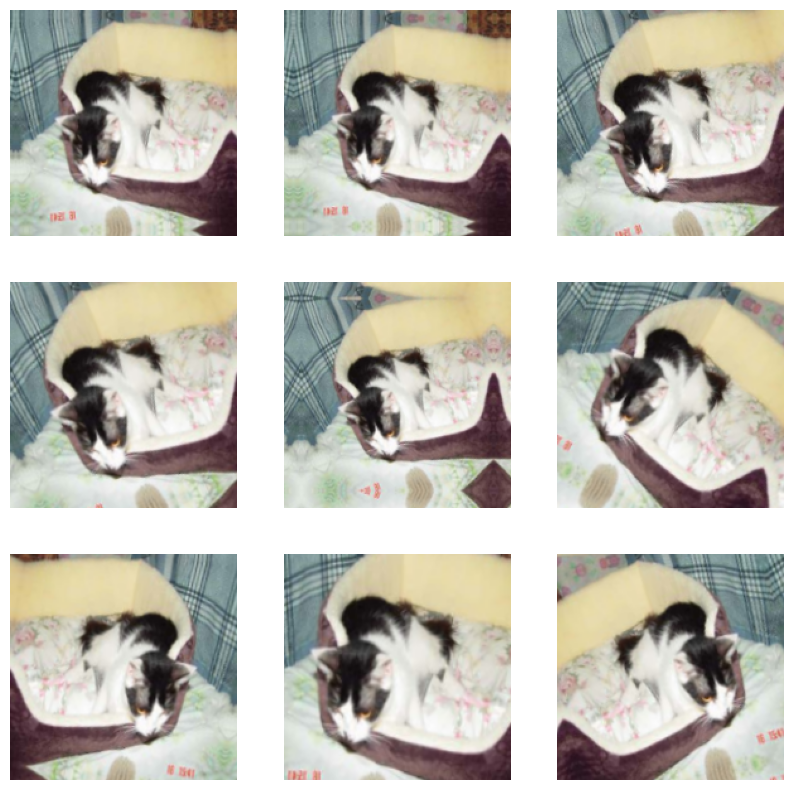

In [21]:
plt.figure(figsize=(10, 10))

# We can use take(N) to only sample N batches from the dataset
for images, _ in train_dataset.take(1):
    for i in range(9):
        # applies the augmentation sequence we created above to the image
        augmented_images = data_augmentation(images)
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_images[0].numpy().astype("uint8"))
        plt.axis("off")

If we train a new model using this data augmentation configuraiton, the model will never see the same input 
twice.  This makes it much harder to memorize the training data.

But the augmented images are still highly intercorrelated, no new information is being produced, we are only remixing
existing information.  As such, this may not be enough to completely get rid of overfitting.  To further fith overfitting,
we'll also add a `Dropout` layer to our model right before the densely connected classifier.

In [22]:
inputs = keras.Input(shape=(180, 180, 3))
x = data_augmentation(inputs)
x = layers.Rescaling(1./255)(x)
x = layers.Conv2D(filters=32, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=64, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=128, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.Flatten()(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs=inputs, outputs=outputs)

In [23]:
model.compile(loss="binary_crossentropy",
              optimizer="rmsprop",
              metrics=["accuracy"])

Let's train the model using data augmentation and dropout.  Because overfitting occurs much later during training, we will
need to train for 3 times as many epochs, 100.

In [24]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="../models/ch08-convnet-from-scratch-with-augmentation.keras",
        save_best_only=True,
        monitor="val_loss")
]

history = model.fit(
    train_dataset,
    epochs=100,
    validation_data=validation_dataset,
    callbacks=callbacks)

Epoch 1/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 59ms/step - accuracy: 0.5155 - loss: 0.7124 - val_accuracy: 0.5010 - val_loss: 0.6928
Epoch 2/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.5057 - loss: 0.6952 - val_accuracy: 0.5230 - val_loss: 0.6911
Epoch 3/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.5816 - loss: 0.6862 - val_accuracy: 0.5040 - val_loss: 0.6916
Epoch 4/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.5597 - loss: 0.6862 - val_accuracy: 0.5290 - val_loss: 0.7038
Epoch 5/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.5740 - loss: 0.6824 - val_accuracy: 0.6110 - val_loss: 0.6548
Epoch 6/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.6321 - loss: 0.6548 - val_accuracy: 0.6170 - val_loss: 0.6477
Epoch 7/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.6420 - loss: 0.6442 - val_accuracy: 0.6300 - val_loss: 0.6338
Epoch 8/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.6458 - loss: 0.6296 - val_accuracy: 0.

Let's plot the learning curve results again.  Thanks to data augmentation and dropout, we start overfitting much later,
around epochs 60-70.  Validation accuracy should end up consistenly in the 80-85% range now for this model.

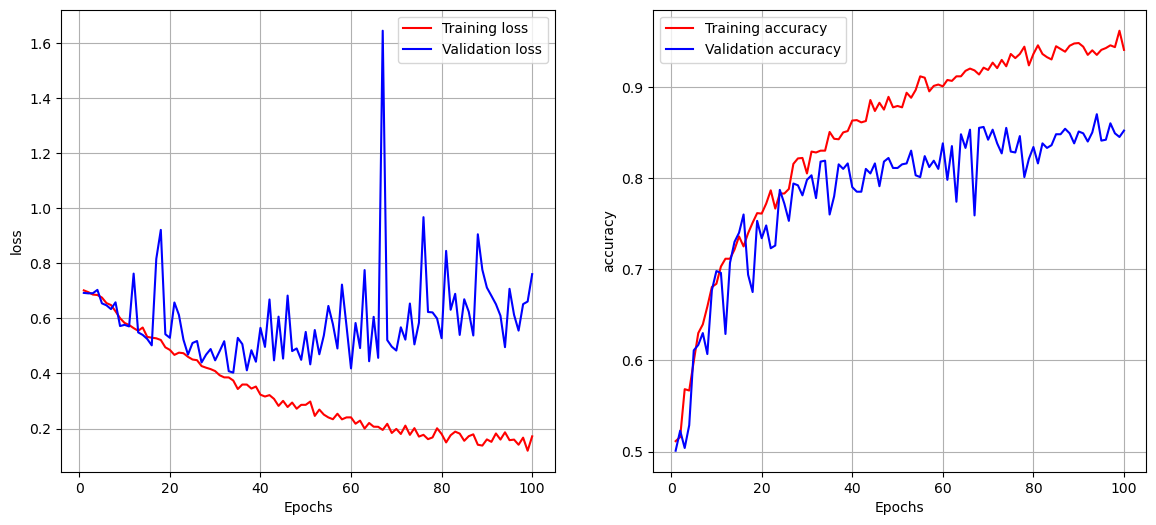

In [25]:
plt.figure(figsize=(14,6))
ax_loss = plt.subplot(1, 2, 1)
plot_history(ax_loss, history.history, 'loss')
ax_acc = plt.subplot(1, 2, 2)
plot_history(ax_acc, history.history, 'accuracy')

Let's also check the accuracy on test data like before.

In [26]:
test_model = keras.models.load_model(
    "../models/ch08-convnet-from-scratch-with-augmentation.keras")

test_loss, test_acc = test_model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.3f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8141 - loss: 0.4134
Test accuracy: 0.804


You should get an accuracy usually above 80% when you run.

By further tuning the model's configurtion (such as the number of filters per convolutoinlayer, or the 
number of layers in themodel) we might be able to gen an even better accuracy, likely up to 90%.  But it would
prove difficult to go higher because of the small amount of data to work with.

## Summary

Some of the important things to keep in mind from this larger example of a convolutional network

<font color='blue'>

- Convnets typically have a sequence of convolution layers followed by maxpooling layers.
- Also typically the number of feature maps will go up for each subsequent convulation in the hierarchy.
- But the maxpooling downsampling will mean that the widthxheight of the layer maps will steadily decrease in size.
  1. because if we don't downsample, the high-level patterns end up still very small for the final feature map
  2. also you get a huge number of coefficients if not downsampling as output to the final dense layer, making overfitting worse
- TensorFlow `Dataset` objects are very useful to help setup dataset workflow into deep learning models
- Data augmentation is a regularization technique that works well with image data